# 03 — Exame médico (câncer de mama) — versão explicada

Este caderno ensina o computador a olhar **30 medidas de células** tiradas de um exame de mama (tamanho, textura, formato...) e dizer se o tumor parece **maligno (1)** ou **benigno (0)**.

Depois de treinar e comparar os modelos, transformamos a resposta do melhor deles num **"semáforo" de três faixas**: decidir sozinho que não, mandar para uma pessoa analisar, ou decidir sozinho que sim.

**Como usar:** rode as células de cima para baixo (menu *Ambiente de execução → Executar tudo*). Cada etapa tem um texto explicando o que vai acontecer, e o código tem um comentário (linhas começando com `#`) dizendo o que cada linha faz.

In [1]:
# Esta célula prepara o ambiente. Sempre rode ela primeiro.
try:
    # Esta linha só funciona dentro do Google Colab
    from google.colab import drive
    # Pede permissão e conecta o seu Google Drive ao Colab
    drive.mount('/content/drive')
    # Endereço da pasta do projeto dentro do Drive (troque se colocou em outro lugar)
    PROJECT_DIR = '/content/drive/MyDrive/a2'
    IN_COLAB = True
except ImportError:
    # Se deu erro acima, não estamos no Colab: usamos a pasta do projeto no computador
    import os
    PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
    IN_COLAB = False
# Entra na pasta do projeto (como dar dois cliques nela)
%cd {PROJECT_DIR}
if IN_COLAB:
    # Instala as bibliotecas listadas no requirements.txt
    !pip install -q -r requirements.txt
# Avisa o Python para procurar o nosso código dentro da pasta do projeto (pasta src/)
import sys; sys.path.insert(0, PROJECT_DIR)

C:\Users\otavi\OneDrive\Desktop\data science\a2


In [2]:
# Qual domínio este caderno vai rodar
DOMAIN = "exame_medico"
# False = usa os modelos já treinados e salvos (rápido). True = treina tudo de novo (demora)
FORCE_RETRAIN = False

# Bibliotecas: gráficos, contas com números e tabelas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Ferramenta para mostrar imagens e tabelas dentro do caderno
from IPython.display import Image, display

# Nosso próprio código, que fica na pasta src/
from src import config, cutoff_hist, evaluate, explain, pipeline
# timed mede quanto tempo cada etapa demora
from src.pipeline import timed

# Configurações deste domínio (classe positiva, métrica, limites de erro...)
cfg = config.DOMAINS[DOMAIN]
# Pasta onde os resultados vão ser salvos: outputs/<domínio>/
OUT = config.output_dir(DOMAIN)
# Subpasta dos resultados da Parte 1 (faixas de decisão)
FX = OUT / "faixas"
# Limiar de decisão: probabilidade >= 0,5 vira "positivo"
T = config.THRESHOLD
# Lista para anotar todas as figuras geradas
FIGS = []

def show(path):
    # Anota a figura na lista e mostra ela na tela
    FIGS.append(path.relative_to(OUT).as_posix())
    display(Image(filename=str(path)))

def table(df, stem):
    # Salva a tabela em CSV e em Markdown dentro de outputs/ e mostra na tela
    evaluate.save_table(df, OUT / stem)
    display(evaluate.round_table(df))

print(f"Domínio: {DOMAIN} | classe positiva: {cfg['positive_question']} | "
      f"métrica-alvo: {cfg['target_metric']} | limiar das métricas: {T}")

Domínio: exame_medico | classe positiva: é maligno? | métrica-alvo: roc_auc | limiar das métricas: 0.5


## 1. Carregar os dados

Lemos o arquivo CSV da base e separamos em duas partes:
- **X** = as características, ou seja, o que o modelo pode olhar;
- **y** = a resposta certa de cada linha: **1** = maligno ("é maligno?") e **0** = benigno.

In [3]:
# Liga o cronômetro desta etapa
with timed("carregar dados"):
    # Lê data/<domínio>.csv e separa em X (características) e y (resposta certa, 0 ou 1)
    X, y = pipeline.load_domain_data(DOMAIN)
# Mostra o tamanho da base e quantos positivos existem
print(f"X: {X.shape} | positivos (target = 1): {y.sum()} ({100 * y.mean():.2f}%)")

[tempo] carregar dados: 0.0 s
X: (569, 30) | positivos (target = 1): 212 (37.26%)


### Conferência importante
No scikit-learn, esta base vem **ao contrário**: 0 = maligno e 1 = benigno. O script `prepare_data.py` inverteu isso. A célula abaixo confere que agora **1 = maligno**, comparando com a base original.

In [4]:
# Carrega a base original do scikit-learn só para comparar
from sklearn.datasets import load_breast_cancer
orig = load_breast_cancer()
# Na base original, maligno é o 0: contamos quantos zeros existem
n_malignos = int((orig.target == 0).sum())
# Se a nossa quantidade de "1" for igual à de malignos da original, a inversão deu certo
assert y.sum() == n_malignos, "target = 1 deveria ser maligno"
print(f"OK: target = 1 corresponde a maligno ({y.sum()} de {len(y)} = {100 * y.mean():.2f}%)")

OK: target = 1 corresponde a maligno (212 de 569 = 37.26%)


## 2. Balanceamento das classes

Contamos quantas linhas são **maligno** e quantas são **benigno**. Isso importa porque, quando uma classe é muito rara, um modelo "preguiçoso" que sempre chuta a classe comum parece ótimo na acurácia, mas não serve para nada.

,classe,n,pct_do_total
0,1 = maligno (é maligno?),212,37.26
1,0 = benigno,357,62.74
2,Total,569,100.00


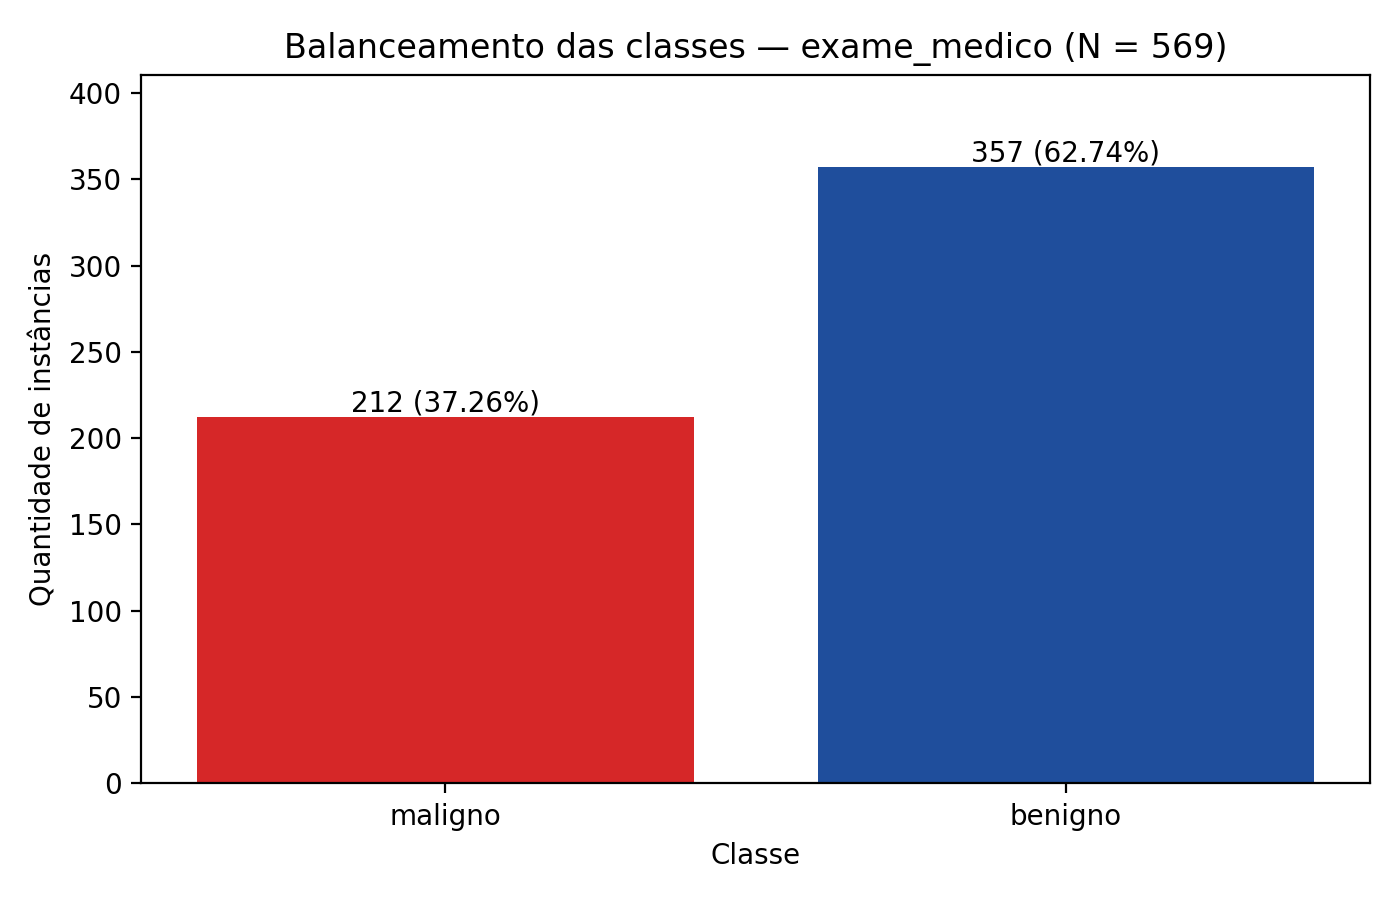

In [5]:
# Monta a tabela com a quantidade e o % de cada classe
balanceamento = evaluate.class_balance_table(y, cfg)
# Salva a tabela em outputs/ e mostra na tela
table(balanceamento, "balanceamento")
# Desenha o gráfico de barras das classes, salva e mostra
show(evaluate.plot_class_balance(y, cfg, OUT / "01_balanceamento_classes.png",
                                 f"Balanceamento das classes — {DOMAIN} (N = {len(y)})"))

## 3. Separar em treino, validação e teste (60% / 20% / 20%)

Pense numa escola:
- **Treino (60%)** = o material de estudo. O modelo aprende aqui.
- **Validação (20%)** = o simulado. Serve para comparar os modelos e escolher o melhor, e para escolher os cortes t1 e t2.
- **Teste (20%)** = a prova final. Só usamos **uma vez**, no fim, para ver a nota verdadeira.

A separação é **estratificada**: cada parte fica com a mesma proporção de maligno da base inteira.

In [6]:
# Liga o cronômetro desta etapa
with timed("split"):
    # Divide em 60% treino, 20% validação e 20% teste, mantendo a proporção de positivos
    splits = pipeline.split_data(X, y)
# Pega as características e as respostas de cada parte
X_tr, y_tr = splits["treino"]
X_val, y_val = splits["validacao"]
X_te, y_te = splits["teste"]
# Mostra o tamanho de cada parte e o % de positivos em cada uma
table(pipeline.split_table(splits), "split")

[tempo] split: 0.0 s


,conjunto,n,pct_do_total,n_positivos,pct_positivos,n_negativos
0,treino,341,59.93,127,37.24,214
1,validacao,114,20.04,43,37.72,71
2,teste,114,20.04,42,36.84,72


## 4. Treinar 3 algoritmos e escolher os melhores "botões" de cada um

Cada algoritmo tem **hiperparâmetros**, que são como botões de regulagem. Para achar a melhor regulagem, usamos **validação cruzada com 5 partes**: o treino é dividido em 5 pedaços; o modelo treina em 4 e é testado no 5º, e isso se repete 5 vezes trocando o pedaço. A nota de cada regulagem é a média das 5 vezes.

Tudo roda dentro de um **Pipeline**: a preparação dos dados (transformar texto em números, padronizar escalas) é aprendida só com o pedaço de treino de cada rodada. Isso evita "cola": o modelo nunca espia os dados em que vai ser avaliado.

Depois de treinado, cada modelo é salvo em `outputs/exame_medico/models/`. Na próxima vez, ele é só carregado, sem precisar treinar de novo.

In [7]:
# Treina (ou carrega, se já estiver salvo) os 3 algoritmos, testando as regulagens por validação cruzada
tuned = pipeline.tune_all(DOMAIN, X_tr, y_tr, force_retrain=FORCE_RETRAIN)
# Monta a tabela com a melhor regulagem de cada algoritmo e a nota média na validação cruzada
hiperparametros = pipeline.hyperparams_table(tuned, cfg["target_metric"])
# Salva e mostra a tabela
table(hiperparametros, "hiperparametros")

[checkpoint] Regressão Logística: carregado de regressao_logistica.joblib
[tempo] tuning Regressão Logística: 0.0 s
[checkpoint] Random Forest: carregado de random_forest.joblib
[tempo] tuning Random Forest: 0.0 s
[checkpoint] SVC (RBF): carregado de svc__rbf.joblib
[tempo] tuning SVC (RBF): 0.0 s


,modelo,metrica_cv,cv_roc_auc_media,cv_roc_auc_desvio,cv_folds,candidatos_testados,tempo_tuning_s,melhores_hiperparametros
0,Regressão Logística,roc_auc,0.9941,0.0078,5,6,28.0622,C=1
1,Random Forest,roc_auc,0.9874,0.0100,5,48,17.8298,max_depth=8; max_features=sqrt; min_samples_le...
2,SVC (RBF),roc_auc,0.9941,0.0083,5,16,0.2136,C=10; gamma=0.01


## 5. Comparar os 3 modelos no "simulado" (validação)

Cada modelo dá, para cada linha, uma **probabilidade de ser maligno**, de 0 a 1. Para decidir "sim" ou "não", usamos o **limiar 0,5**: probabilidade ≥ 0,5 vira maligno.

- **Acurácia**: % de acertos no geral.
- **Precisão**: quando o modelo diz "maligno", quantas vezes ele acerta?
- **Recall**: de todos os maligno que existem, quantos o modelo encontrou?
- **F1**: junta precisão e recall numa nota só.
- **ROC-AUC**, **PR-AUC** e **AP**: notas que não dependem do limiar (explicadas na etapa 7).
- **Matriz de confusão**: tabela com os 4 tipos de resultado (acertos e erros de cada lado).

[tempo] avaliação na validação: 0.0 s


,modelo,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,0.5,0.9737,0.9545,0.9767,0.9655,0.9957,0.9946,0.9946,69,2,1,42
1,Random Forest,0.5,0.9737,0.9762,0.9535,0.9647,0.9885,0.9864,0.9865,70,1,2,41
2,SVC (RBF),0.5,0.9649,0.9333,0.9767,0.9545,0.9957,0.9946,0.9946,68,3,1,42


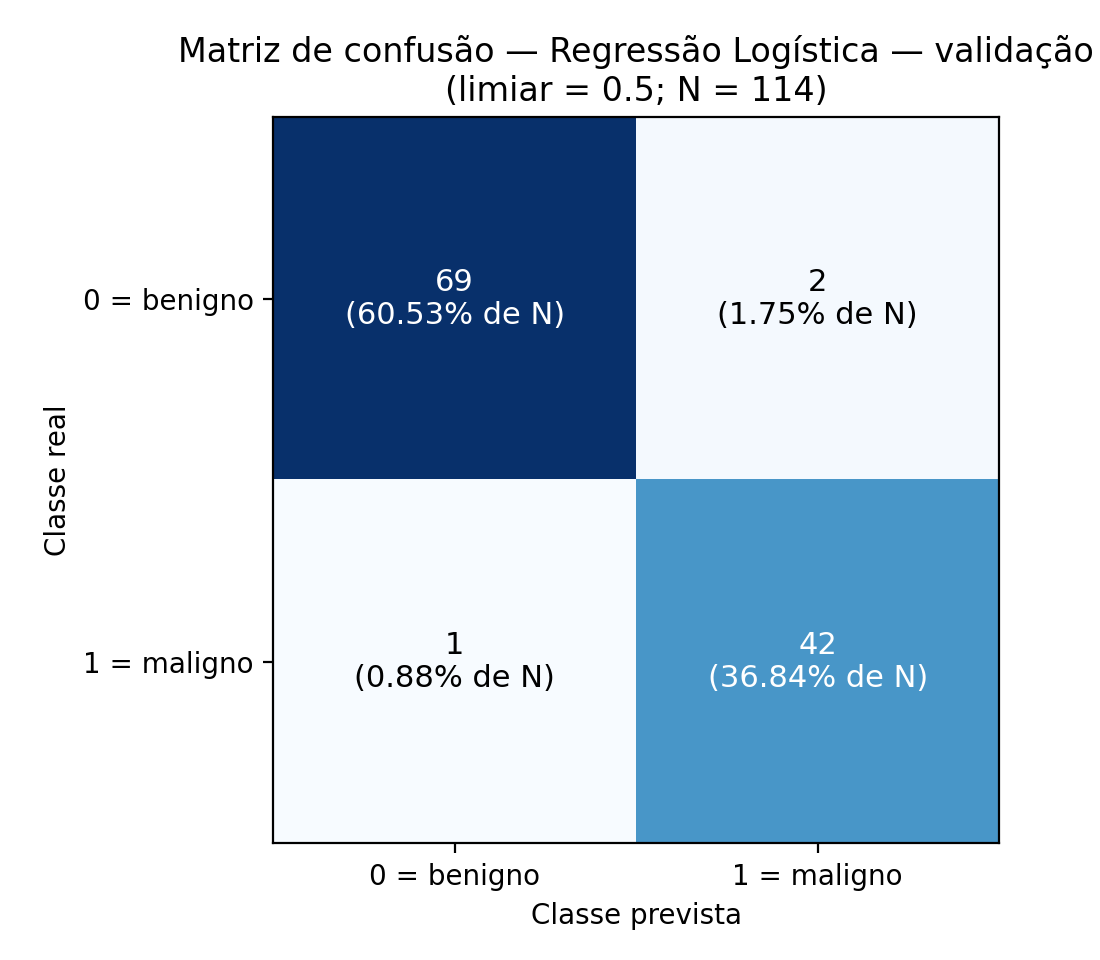

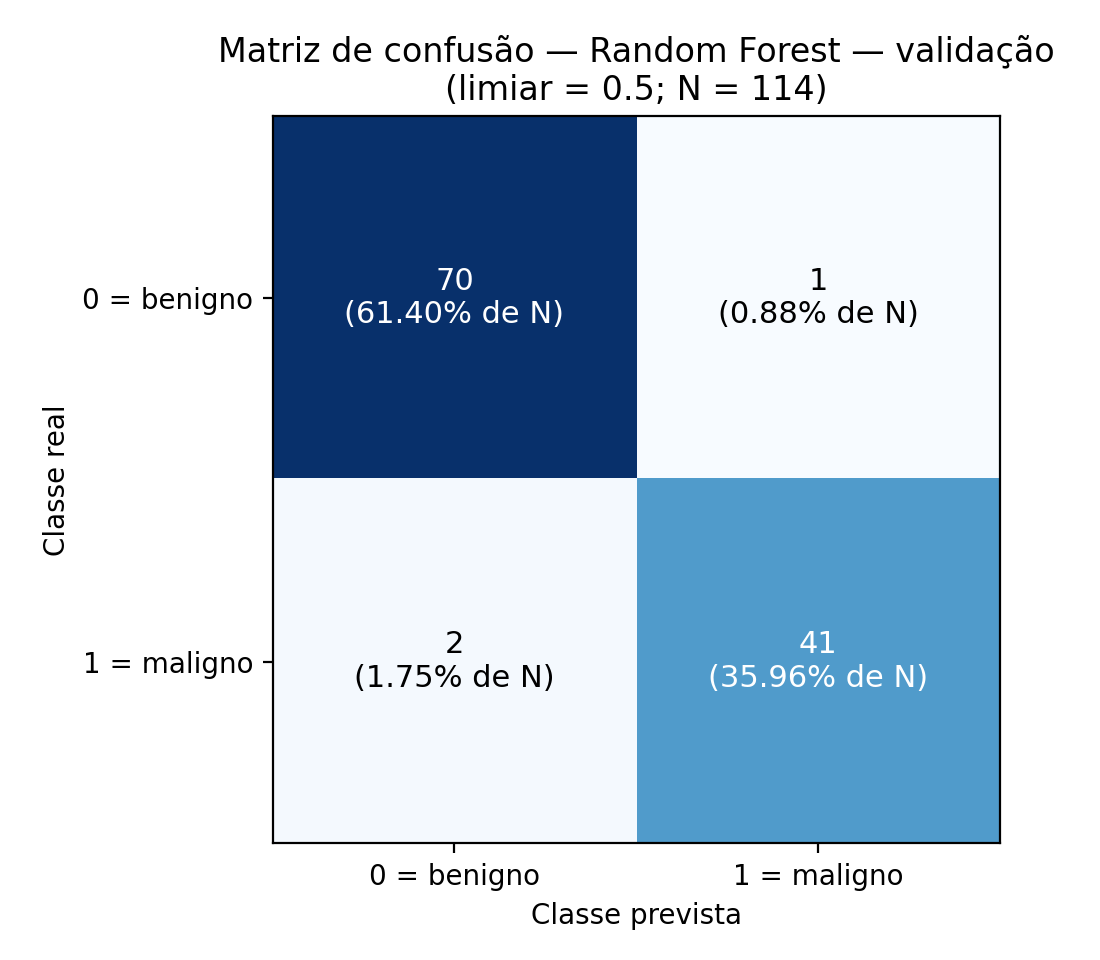

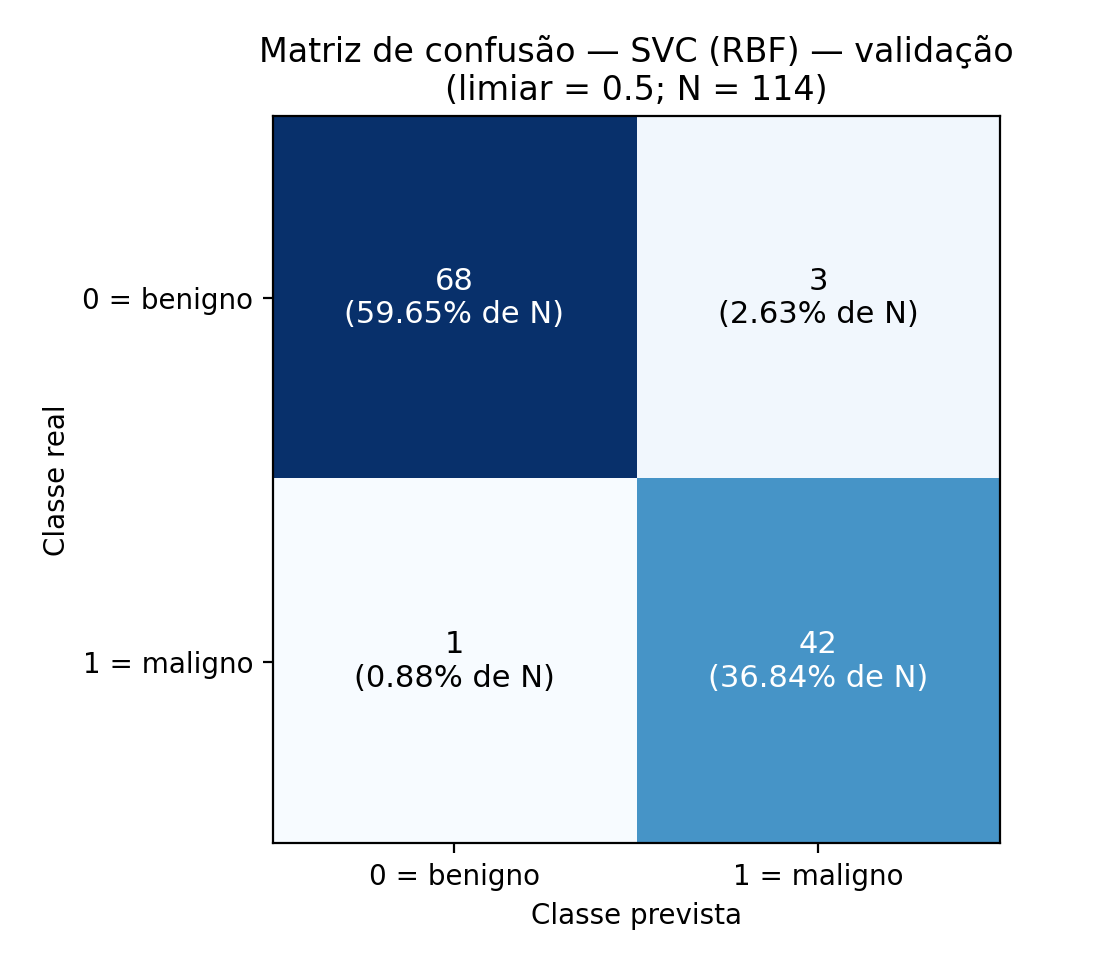

In [8]:
# Liga o cronômetro desta etapa
with timed("avaliação na validação"):
    # Para cada modelo, calcula a probabilidade de ser positivo de TODAS as linhas da validação
    val_probas = {name: pipeline.predict_positive(ck["estimator"], X_val)
                  for name, ck in tuned.items()}
    # Calcula todas as métricas de cada modelo (limiar 0,5 nas que precisam de decisão)
    comparacao = evaluate.comparison_table(y_val, val_probas)
# Salva e mostra a tabela comparando os 3 modelos
table(comparacao, "comparacao_validacao")
# Para cada modelo, desenha a matriz de confusão
for name, p in val_probas.items():
    show(evaluate.plot_confusion(
        y_val, p, cfg, OUT / f"02_matriz_confusao_validacao_{pipeline.slug(name)}.png",
        f"Matriz de confusão — {name} — validação"))

## 6. Escolher o melhor modelo

O vencedor é o de maior nota na métrica escolhida para este domínio: **ROC-AUC**. As duas classes aparecem em quantidades parecidas (37% malignos), então queremos um modelo que coloque os doentes "na frente" dos saudáveis quando ordenamos todos por risco. A ROC-AUC mede exatamente isso.

In [9]:
# Escolhe o modelo com a maior métrica-alvo na validação
best_name, best_col, best_value = evaluate.select_best(comparacao, cfg["target_metric"])
# Guarda o modelo vencedor para usar nas próximas etapas
best = tuned[best_name]["estimator"]
# Frase que resume a escolha
selecao = f"{best_name} — maior {best_col} na validação = {best_value:.4f}"
print("Melhor modelo:", selecao)

Melhor modelo: Regressão Logística — maior roc_auc na validação = 0.9957


## 7. Curvas ROC e Precisão-Revocação (PR)

Em vez de usar só o limiar 0,5, as curvas testam **todos os limiares** de 0 a 1:
- **Curva ROC**: para cada limiar, marca um ponto com a taxa de alarmes falsos (eixo X) e a taxa de maligno encontrados (eixo Y). A **área embaixo da curva (ROC-AUC)** vai de 0,5 (chute) a 1 (perfeito).
- **Curva PR**: para cada limiar, marca um ponto com o recall (eixo X) e a precisão (eixo Y). A linha tracejada é o chute (a proporção de maligno). A área pode ser calculada de dois jeitos: **PR-AUC trapezoidal** (liga os pontos com retas) e **Average Precision** (soma em degraus).

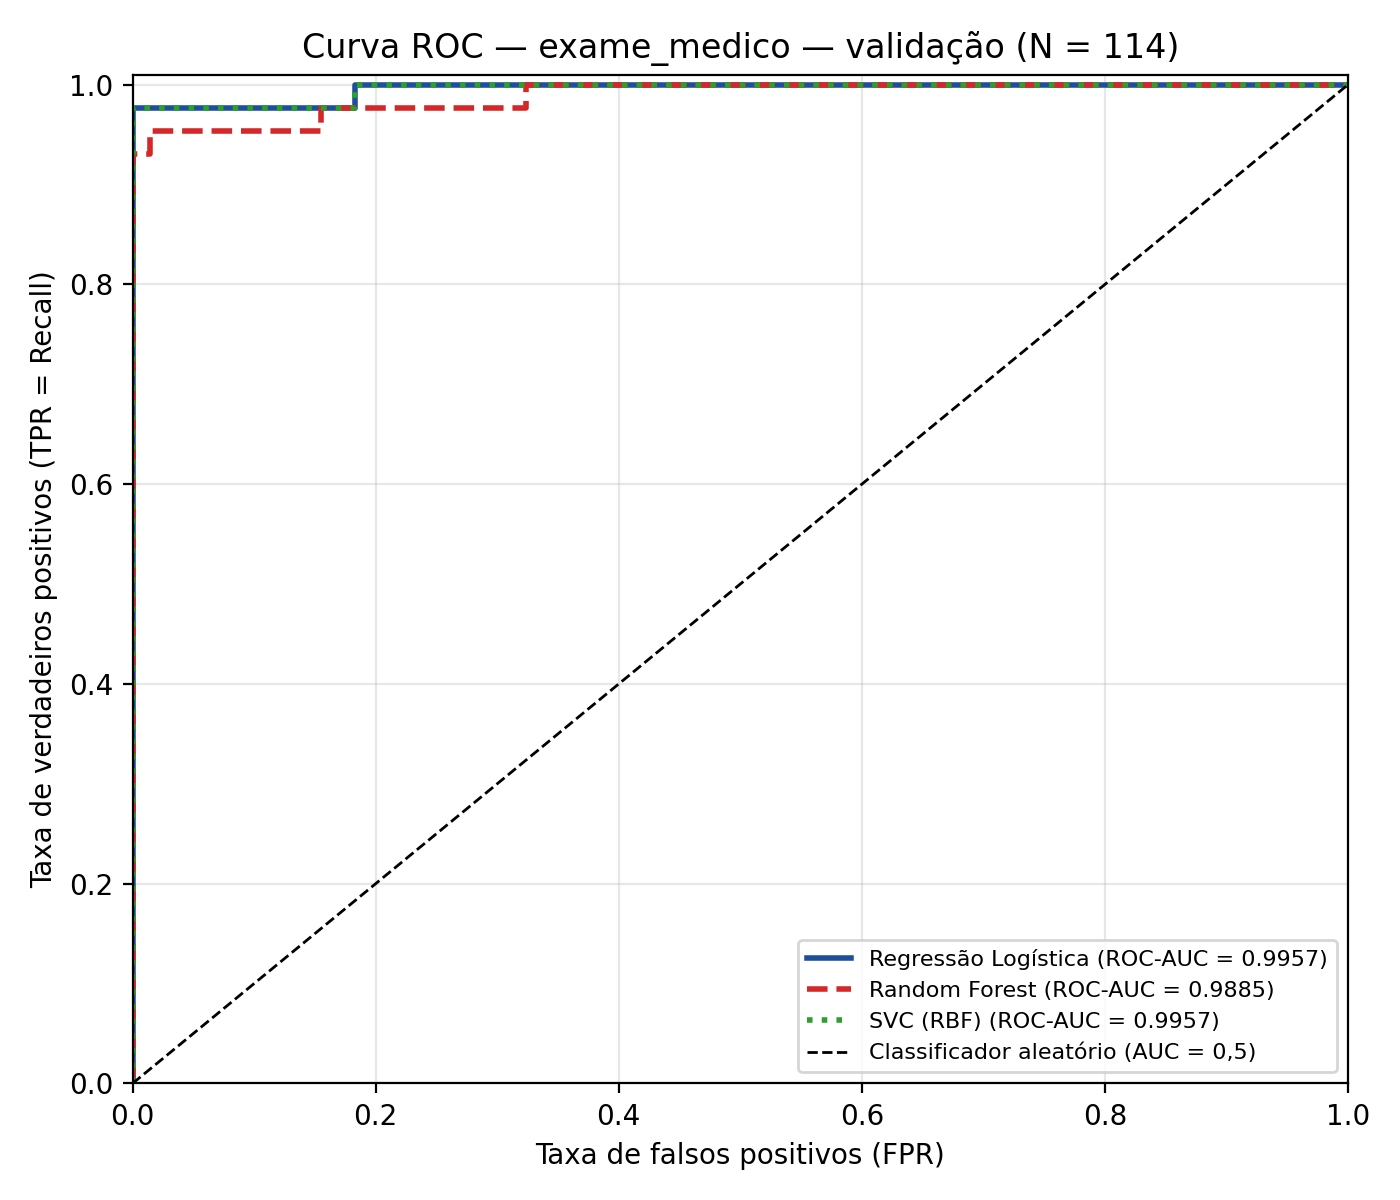

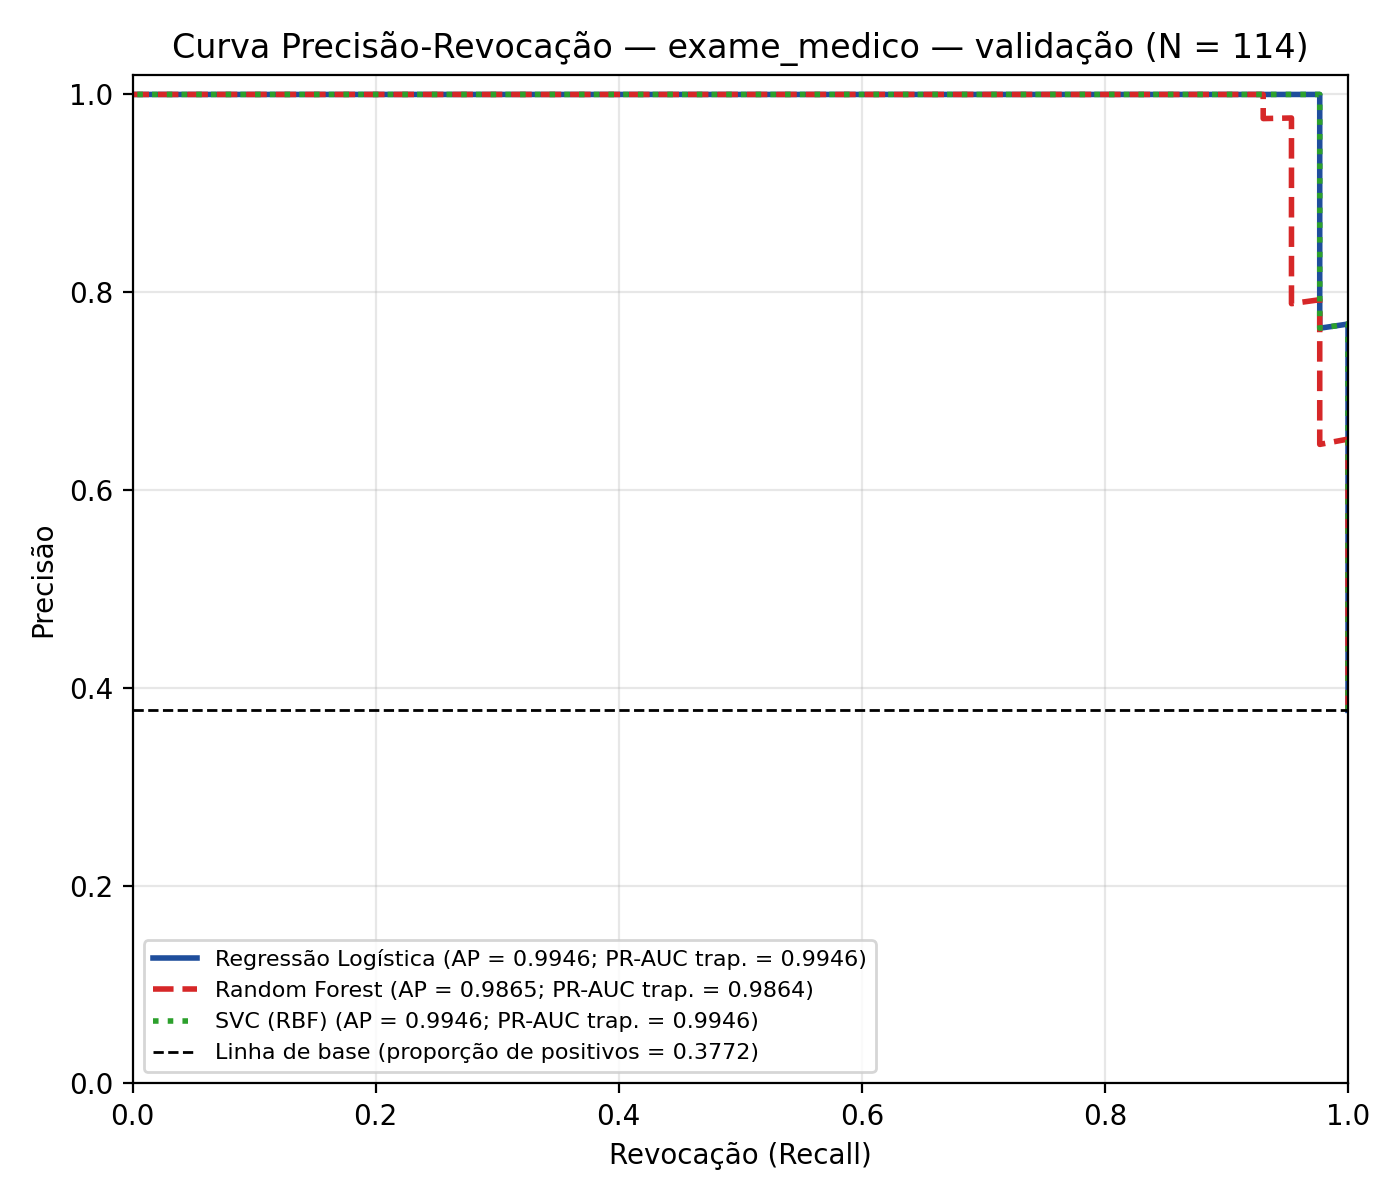

In [10]:
# Quantidade de linhas da validação (vai no título dos gráficos)
n_val = len(y_val)
# Desenha as curvas ROC dos 3 modelos juntas
show(evaluate.plot_roc(y_val, val_probas, OUT / "03_curva_roc_validacao.png",
                       f"Curva ROC — {DOMAIN} — validação (N = {n_val})"))
# Desenha as curvas Precisão-Revocação dos 3 modelos juntas
show(evaluate.plot_pr(y_val, val_probas, OUT / "04_curva_pr_validacao.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — validação (N = {n_val})"))

## 8. O que acontece quando mudamos o limiar

Esta tabela mostra o melhor modelo com limiares de 0,1 a 0,9. Limiar **baixo** = o modelo diz "maligno" com facilidade: encontra mais maligno, mas dá mais alarmes falsos. Limiar **alto** = o contrário. Cada linha da tabela é um ponto das curvas da etapa 7.

In [11]:
# Calcula acertos e erros do melhor modelo para os limiares 0,1; 0,2; ...; 0,9
varredura = evaluate.threshold_sweep(y_val, val_probas[best_name])
# Salva e mostra a tabela
table(varredura, "varredura_limiar")

,limiar,TP,FP,TN,FN,TPR_recall,FPR,precisao
0,0.1,43,13,58,0,1.0000,0.1831,0.7679
1,0.2,42,8,63,1,0.9767,0.1127,0.8400
2,0.3,42,4,67,1,0.9767,0.0563,0.9130
3,0.4,42,2,69,1,0.9767,0.0282,0.9545
4,0.5,42,2,69,1,0.9767,0.0282,0.9545
5,0.6,42,2,69,1,0.9767,0.0282,0.9545
6,0.7,42,0,71,1,0.9767,0.0000,1.0000
7,0.8,42,0,71,1,0.9767,0.0000,1.0000
8,0.9,42,0,71,1,0.9767,0.0000,1.0000


## 9. A "prova final": avaliar o melhor modelo no teste

Agora, e só agora, usamos o teste. O modelo **não é retreinado e nada é ajustado**: é a nota verdadeira, em dados que o modelo nunca viu e que não influenciaram nenhuma escolha.

[tempo] avaliação no teste: 0.0 s


,modelo,conjunto,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,teste,0.5,0.9737,0.9756,0.9524,0.9639,0.9954,0.9935,0.9936,71,1,2,40


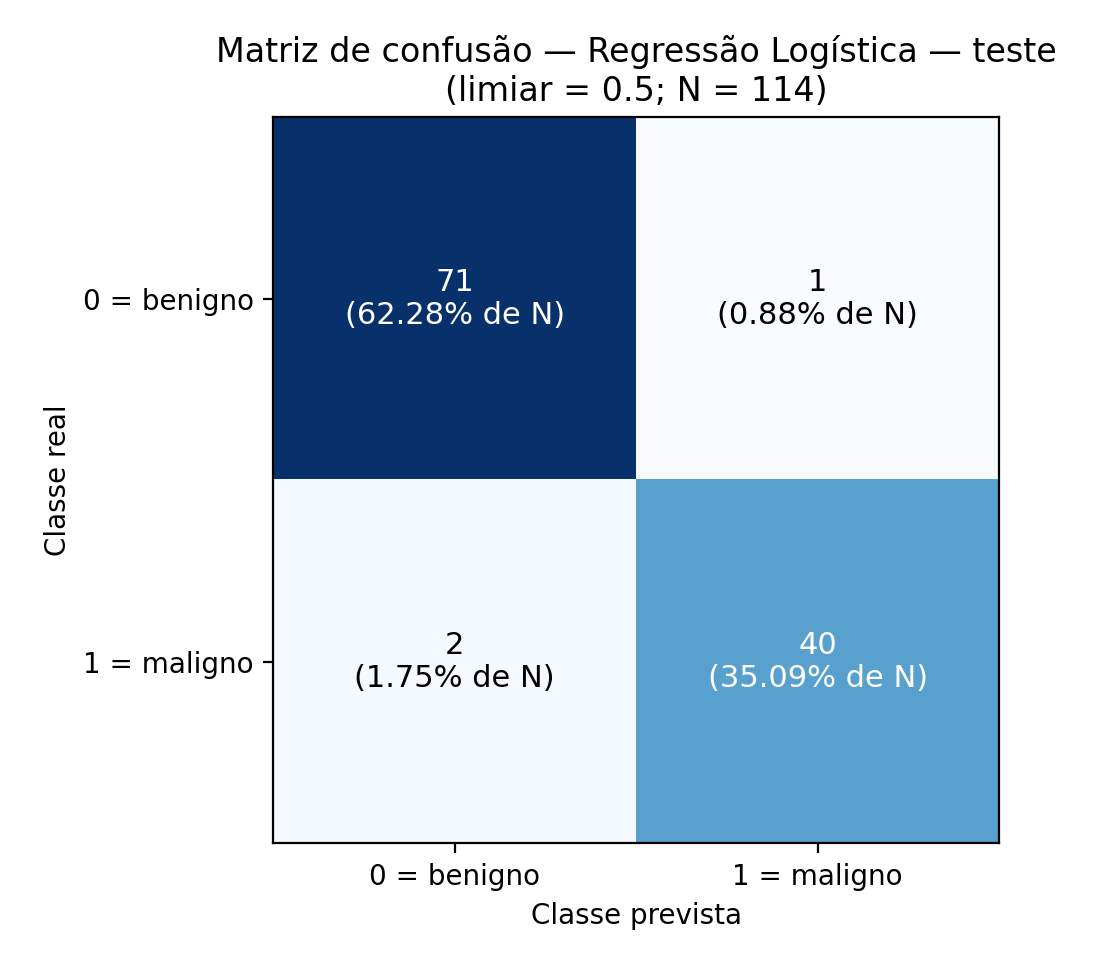

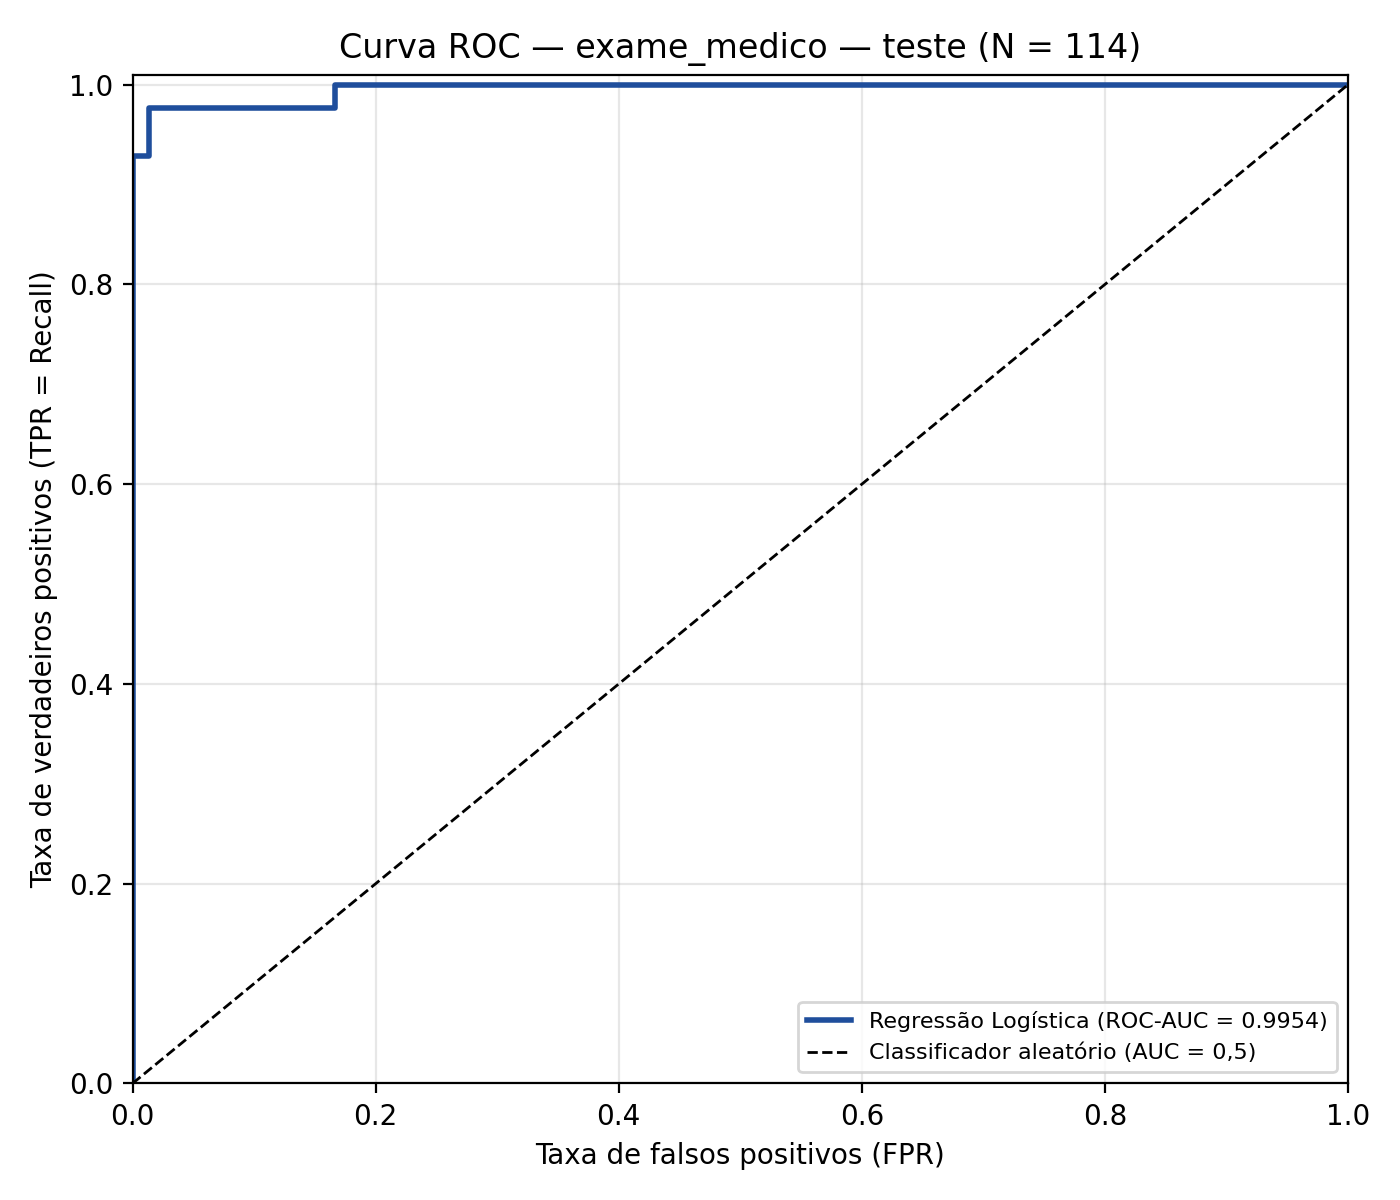

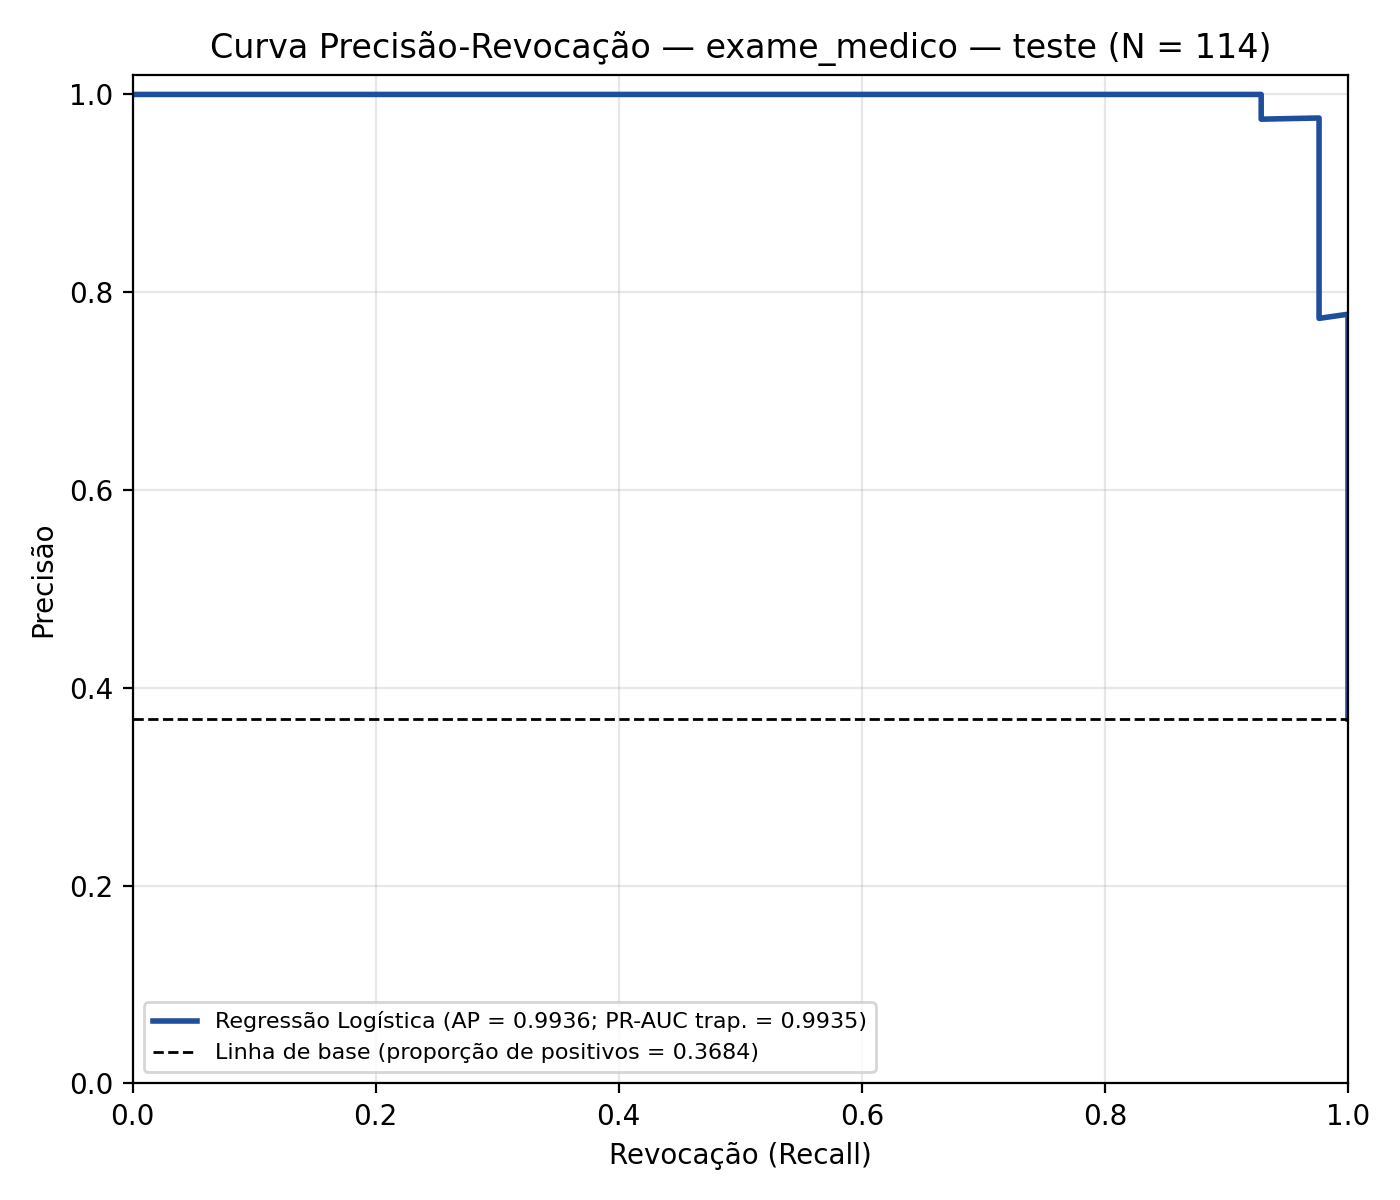

In [12]:
# Liga o cronômetro desta etapa
with timed("avaliação no teste"):
    # Probabilidade de ser positivo para TODAS as linhas do teste
    p_test = pipeline.predict_positive(best, X_te)
    # Calcula as mesmas métricas da etapa 5, agora no teste
    resultado_teste = evaluate.comparison_table(y_te, {best_name: p_test})
# Acrescenta uma coluna dizendo que estes números são do teste
resultado_teste.insert(1, "conjunto", "teste")
# Salva e mostra a tabela
table(resultado_teste, "resultado_teste")
# Quantidade de linhas do teste (vai no título dos gráficos)
n_te = len(y_te)
# Matriz de confusão, curva ROC e curva PR do melhor modelo no teste
show(evaluate.plot_confusion(y_te, p_test, cfg, OUT / "05_matriz_confusao_teste.png",
                             f"Matriz de confusão — {best_name} — teste"))
show(evaluate.plot_roc(y_te, {best_name: p_test}, OUT / "06_curva_roc_teste.png",
                       f"Curva ROC — {DOMAIN} — teste (N = {n_te})"))
show(evaluate.plot_pr(y_te, {best_name: p_test}, OUT / "07_curva_pr_teste.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — teste (N = {n_te})"))

## 10. SHAP: o que o modelo levou em conta?

O SHAP mostra **quanto cada característica empurrou a resposta do modelo para cima ou para baixo**. Como ler o gráfico:
- cada **linha** é uma característica, e a mais importante fica no topo;
- cada **ponto** é uma linha do teste;
- ponto à **direita** do zero = aquela característica aumentou a chance de maligno; à **esquerda** = diminuiu;
- **cor**: vermelho = valor alto da característica; azul = valor baixo.

O texto impresso embaixo do gráfico diz qual saída do modelo foi explicada e quais dados foram usados.

[tempo] SHAP: 2.9 s


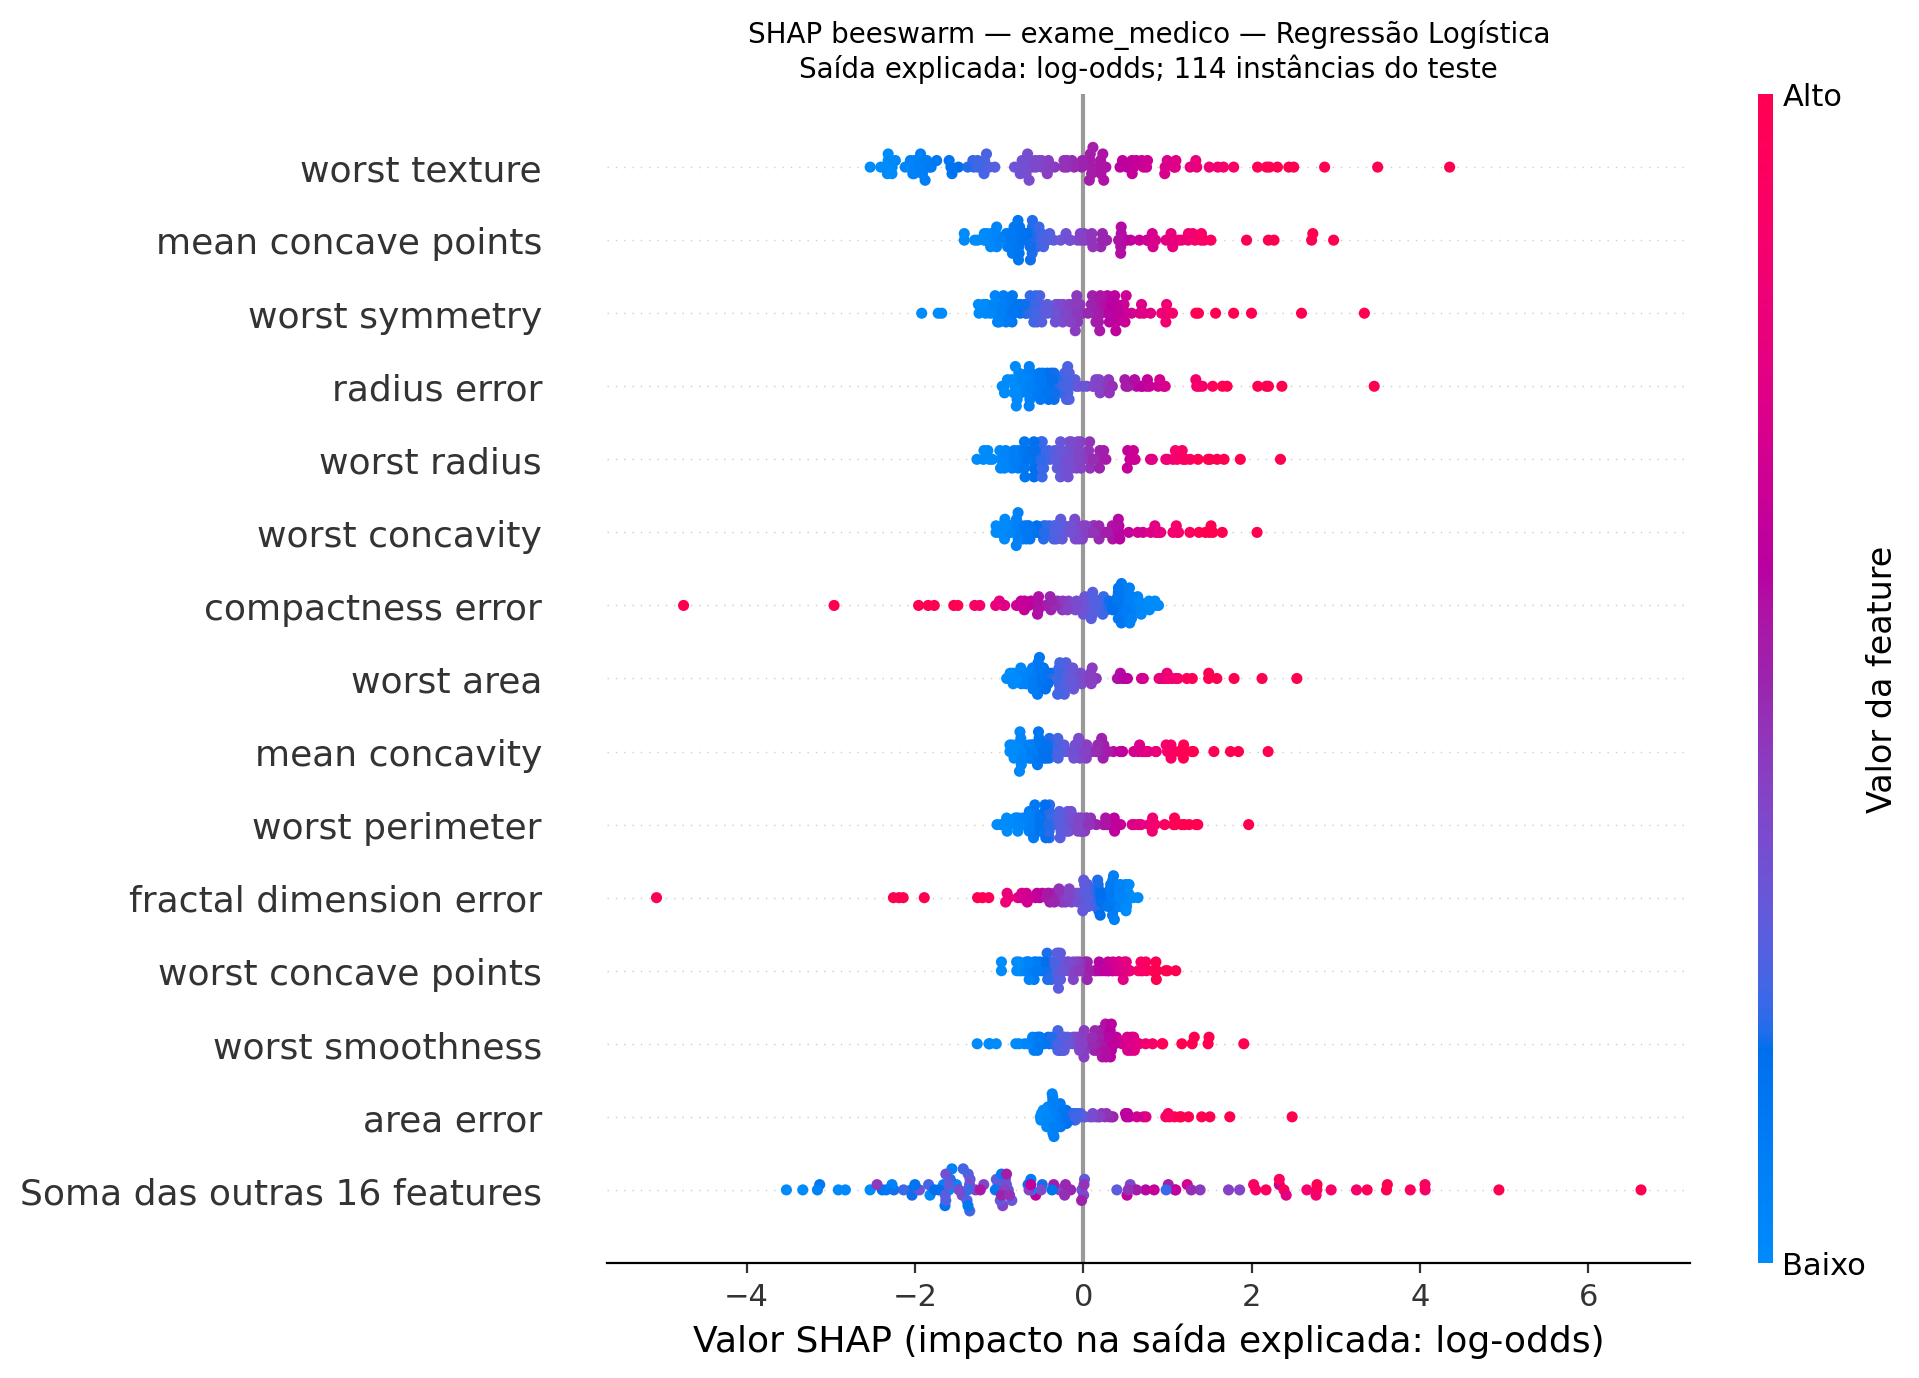

Domínio: exame_medico
Modelo explicado: Regressão Logística (LogisticRegression)
Explainer: LinearExplainer (interventional)
Saída do modelo explicada: log-odds (escala linear) da classe positiva da Regressão Logística
Dados explicados: 114 instâncias aleatórias do conjunto de TESTE (random_state=42), transformadas pelo pré-processamento do pipeline
Conjunto de fundo (background): 100 instâncias aleatórias do TREINO
Número de features após o pré-processamento: 30
Beeswarm: max_display=15; cor = valor da feature (vermelho alto, azul baixo); eixo X = contribuição SHAP para a saída explicada


,posicao,feature,media_abs_shap,correlacao_valor_shap,leitura
0,1,worst texture,1.1791,1.0,valores altos aumentam a saída
1,2,mean concave points,0.8246,1.0,valores altos aumentam a saída
2,3,worst symmetry,0.6661,1.0,valores altos aumentam a saída
3,4,radius error,0.6407,1.0,valores altos aumentam a saída
4,5,worst radius,0.6103,1.0,valores altos aumentam a saída
5,6,worst concavity,0.5825,1.0,valores altos aumentam a saída
6,7,compactness error,0.5674,-1.0,valores altos diminuem a saída
7,8,worst area,0.5582,1.0,valores altos aumentam a saída
8,9,mean concavity,0.5568,1.0,valores altos aumentam a saída
9,10,worst perimeter,0.4912,1.0,valores altos aumentam a saída


In [13]:
# Liga o cronômetro desta etapa
with timed("SHAP"):
    # Calcula o SHAP numa amostra de até 1.000 linhas do teste, usando 100 linhas do treino como referência
    shap_res = explain.explain_model(DOMAIN, best_name, best, X_tr, X_te, OUT,
                                     OUT / "08_shap_beeswarm.png")
# Mostra o gráfico beeswarm
show(OUT / "08_shap_beeswarm.png")
# Mostra qual saída foi explicada e quais dados foram usados
print("\n".join(shap_res["info"]))
# Mostra as 10 características mais importantes
display(evaluate.round_table(shap_res["top10"]))

## 11. Parte 1: o "semáforo" de decisões

Com a probabilidade do melhor modelo, criamos três faixas usando dois cortes, **t1** e **t2**:
- 🟢 **p < t1** → o sistema decide **benigno** sozinho;
- 🟡 **t1 ≤ p < t2** → **uma pessoa analisa**;
- 🔴 **p ≥ t2** → o sistema decide **maligno** sozinho.

**Como os cortes são escolhidos:** só na validação, testando todos os pares de 0,00 a 1,00. Um par só vale se respeitar os limites de erro deste domínio. Aqui, o erro mais grave é dizer que um tumor maligno é benigno (a pessoa não seria tratada a tempo), e o mais leve é dizer que um benigno é maligno (a pessoa faz um exame extra e descobre que está tudo bem). Entre os pares que valem, fica o que manda **menos casos para a pessoa analisar**.

**No histograma:** o eixo X é a probabilidade de 0% a 100%. As barras **azuis** são todas as linhas e as **vermelhas** são só as que são maligno de verdade. **As duas usam o mesmo total N** como base do %.

t1 = 0.10 | t2 = 0.21  (max_fn_rate = 0.01 sobre positivos, max_fp_rate = 0.1 sobre negativos)


,t1,t2,volume_manual,cobertura_automatica,fn_auto,fn_auto_sobre_positivos,fp_auto,fp_auto_sobre_negativos,violacao,viavel
0,0.10,0.21,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
1,0.10,0.22,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
2,0.10,0.23,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
3,0.10,0.24,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
4,0.10,0.25,0.0614,0.9386,0,0.0,7,0.0986,0.0,True
5,0.10,0.26,0.0702,0.9298,0,0.0,6,0.0845,0.0,True
6,0.09,0.21,0.0702,0.9298,0,0.0,7,0.0986,0.0,True
7,0.09,0.22,0.0702,0.9298,0,0.0,7,0.0986,0.0,True
8,0.09,0.23,0.0702,0.9298,0,0.0,7,0.0986,0.0,True
9,0.09,0.24,0.0702,0.9298,0,0.0,7,0.0986,0.0,True


,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,58,50.88,0,0.00,58,100.00
1,Análise manual,t1 ≤ p < t2,7,6.14,1,14.29,6,85.71
2,Positiva automática,p ≥ t2,49,42.98,42,85.71,7,14.29
3,Total,"t1 = 0.1, t2 = 0.21",114,100.00,43,37.72,71,62.28


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,0.0000,NaN,0,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0000,0.00,0,43,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0000,0.00,0,114,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,7.0000,NaN,7,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0986,9.86,7,71,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0614,6.14,7,114,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9386,93.86,107,114,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0614,6.14,7,114,N (total de instâncias),proporção de N encaminhada à análise manual


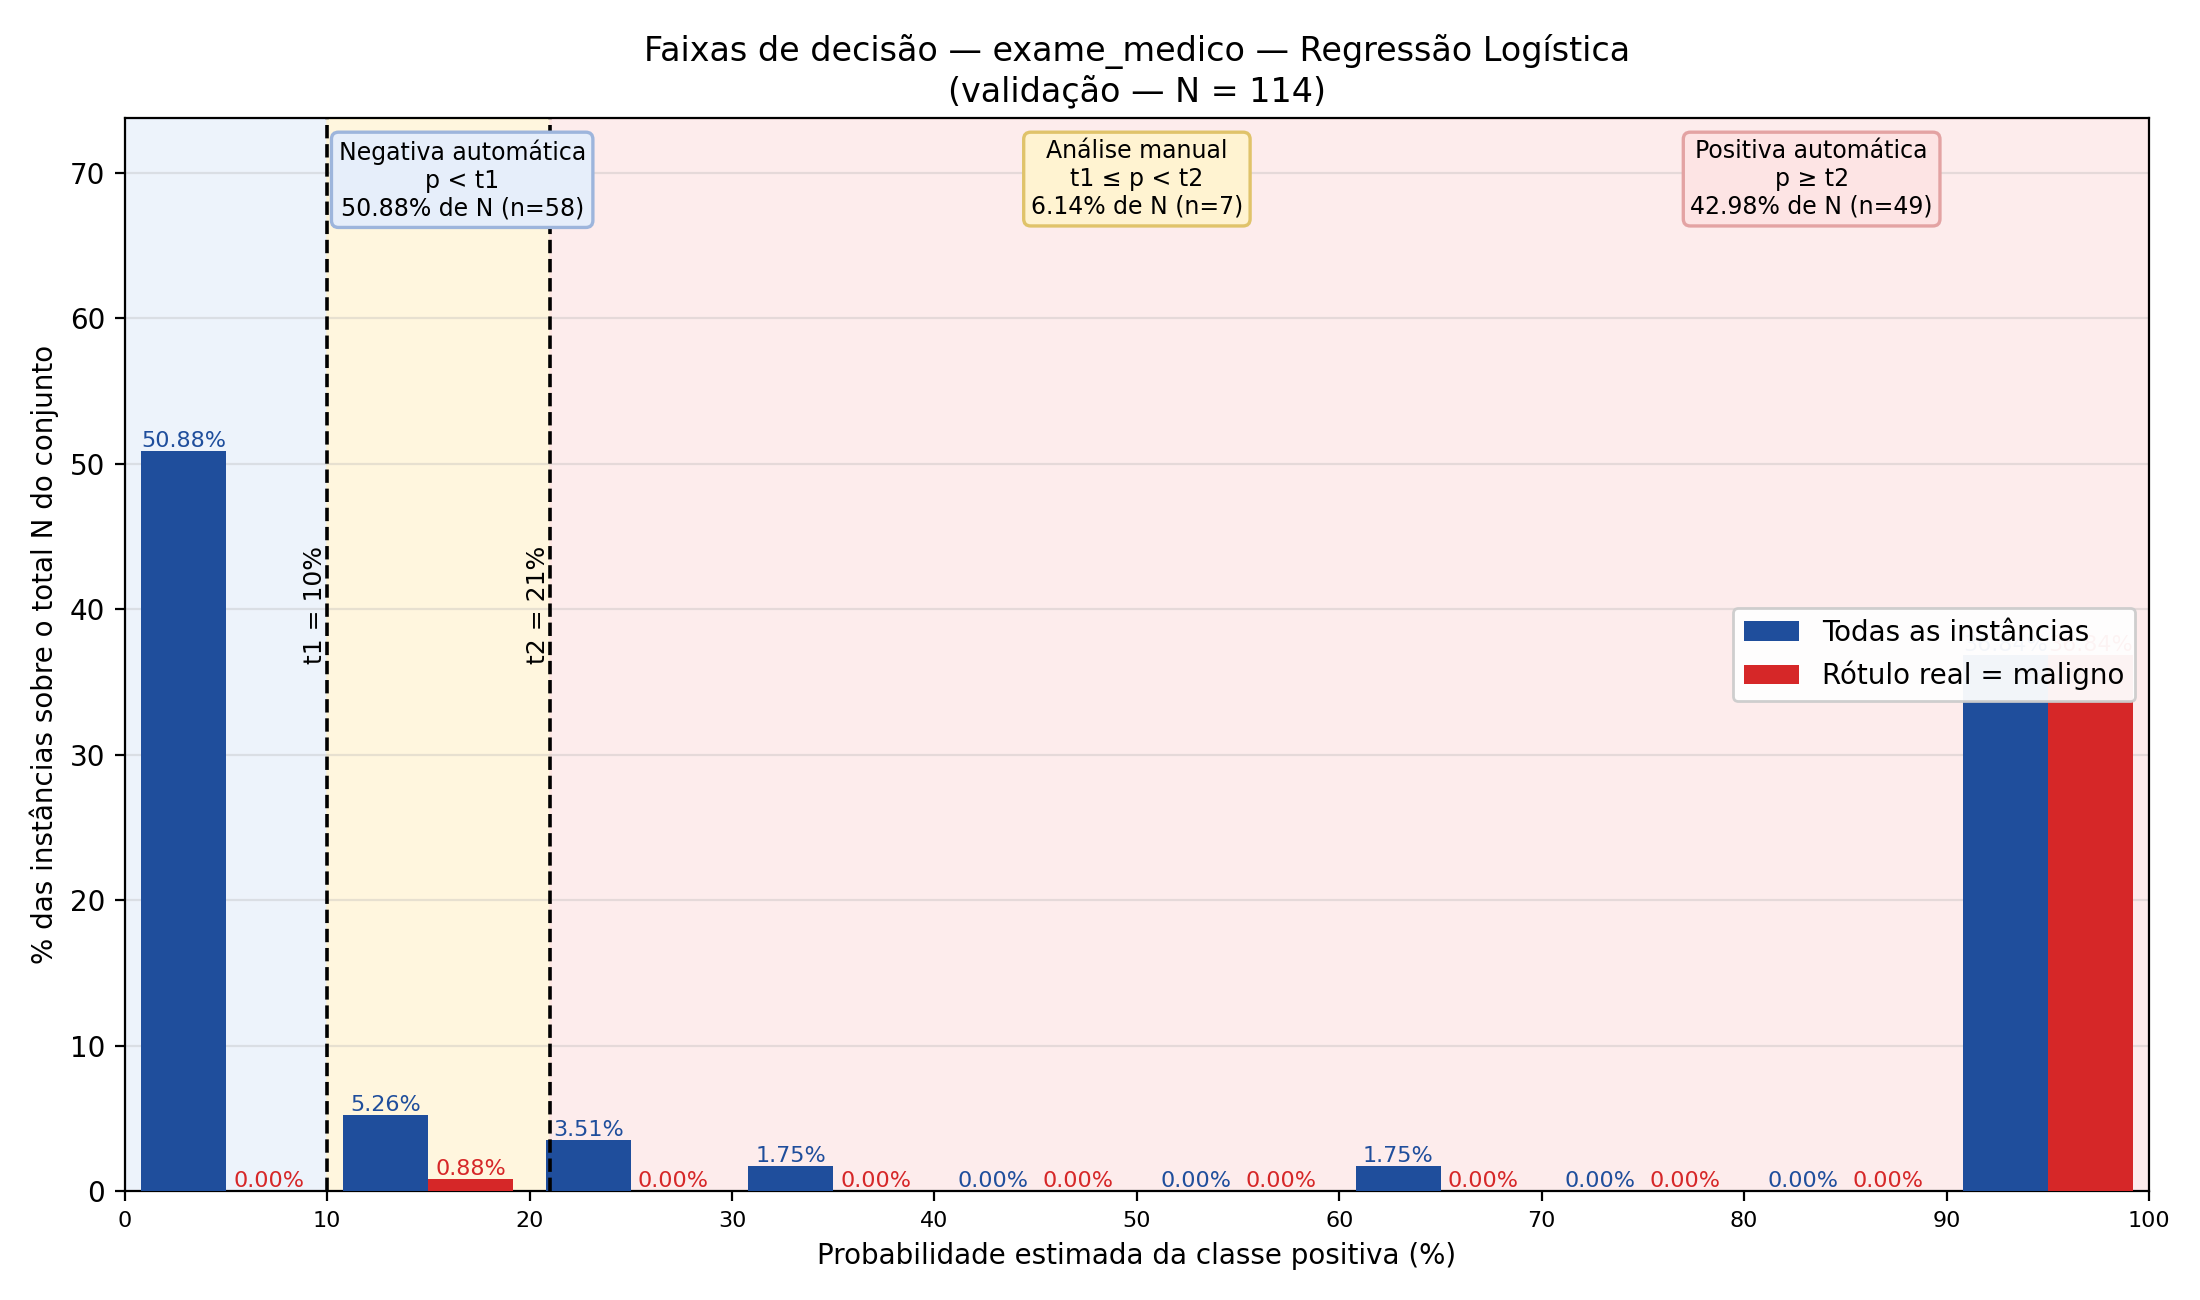

In [14]:
# Probabilidades do melhor modelo na validação
p_val = val_probas[best_name]
# Procura o melhor par (t1, t2) SÓ na validação, respeitando os limites de erro do domínio
(t1, t2), rep_val, tradeoff = cutoff_hist.choose_cutoffs(
    y_val, p_val, cfg["max_fn_rate"], cfg["max_fp_rate"])
print(f"t1 = {t1:.2f} | t2 = {t2:.2f}  (max_fn_rate = {cfg['max_fn_rate']} sobre positivos, "
      f"max_fp_rate = {cfg['max_fp_rate']} sobre negativos)")
# Tabela com os 10 melhores pares de cortes encontrados
table(tradeoff, "faixas/tradeoff_validacao")
# Quantos casos caíram em cada faixa e quantos positivos e negativos há em cada uma
table(rep_val["faixas"], "faixas/band_report_validacao_faixas")
# Erros das decisões automáticas, com o denominador de cada proporção
table(rep_val["erros"], "faixas/band_report_validacao_erros")
# Desenha o histograma com as faixas na validação
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_val, p_val, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "09_histograma_faixas_validacao.png",
    dataset_name="validação")
# Fecha a figura (já foi salva) e mostra a imagem salva
plt.close(fig)
show(FX / "09_histograma_faixas_validacao.png")

### 11b. Os mesmos cortes aplicados ao teste

Usamos **exatamente o mesmo t1 e t2** no teste, sem nenhum ajuste. Se os erros no teste passarem um pouco dos limites, isso é normal: os cortes foram escolhidos numa amostra e aplicados em outra.

,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,66,57.89,1,1.52,65,98.48
1,Análise manual,t1 ≤ p < t2,3,2.63,0,0.00,3,100.00
2,Positiva automática,p ≥ t2,45,39.47,41,91.11,4,8.89
3,Total,"t1 = 0.1, t2 = 0.21",114,100.00,42,36.84,72,63.16


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,1.0000,NaN,1,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0238,2.38,1,42,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0088,0.88,1,114,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,4.0000,NaN,4,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0556,5.56,4,72,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0351,3.51,4,114,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9737,97.37,111,114,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0263,2.63,3,114,N (total de instâncias),proporção de N encaminhada à análise manual


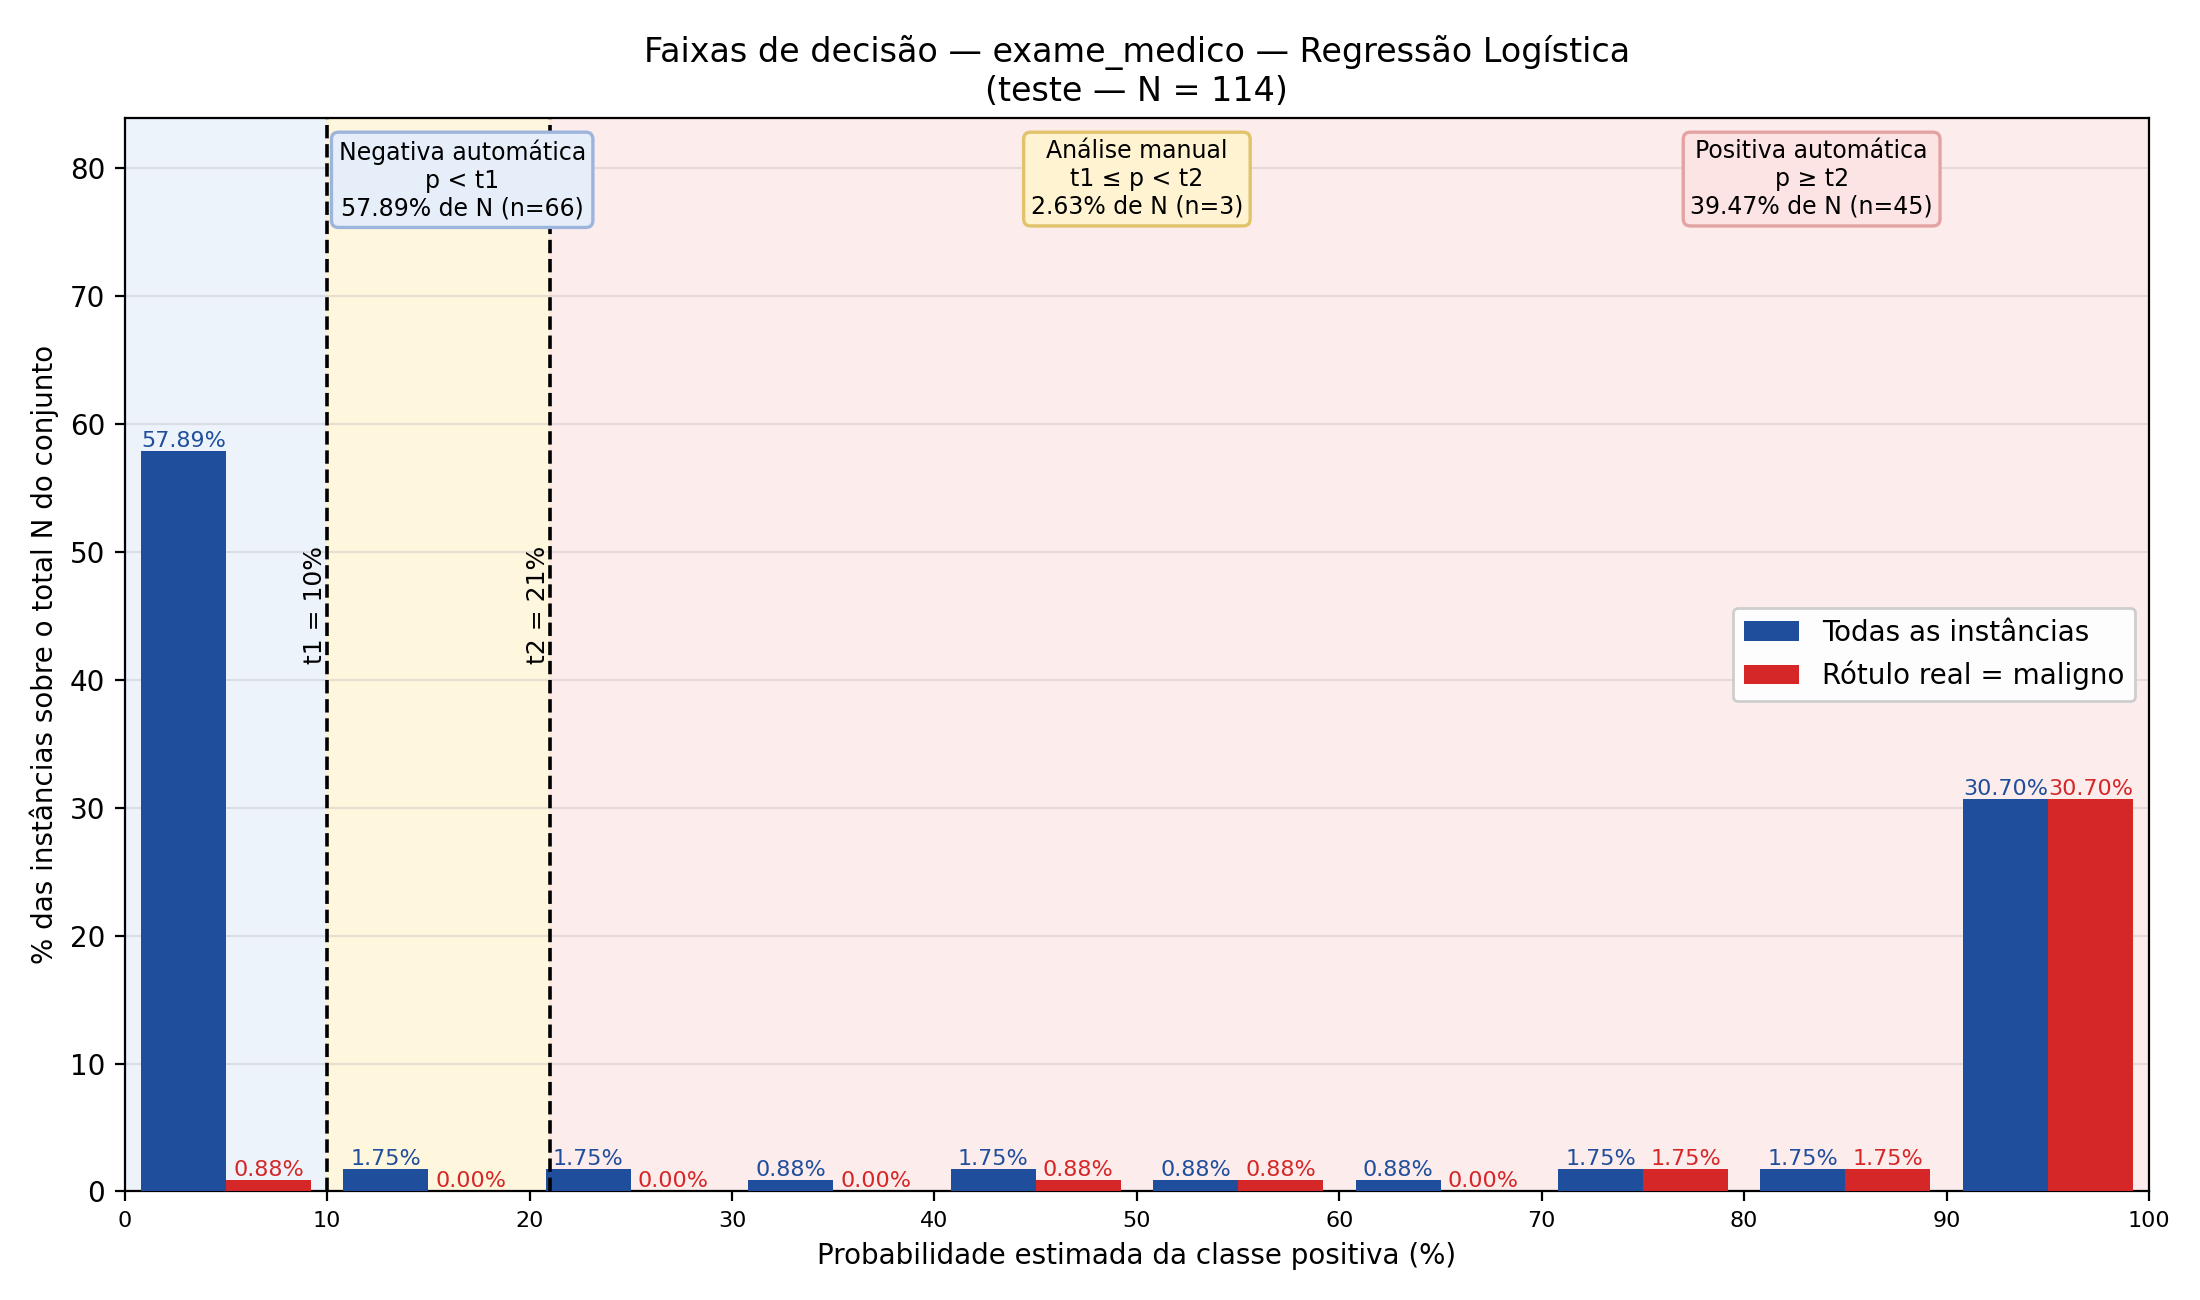

In [15]:
# Mesmas tabelas da validação, agora no teste, com os MESMOS t1 e t2
rep_test = cutoff_hist.band_report(y_te, p_test, t1, t2)
table(rep_test["faixas"], "faixas/band_report_teste_faixas")
table(rep_test["erros"], "faixas/band_report_teste_erros")
# Desenha o histograma com as faixas no teste
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_te, p_test, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "10_histograma_faixas_teste.png",
    dataset_name="teste")
plt.close(fig)
show(FX / "10_histograma_faixas_teste.png")
# Salva a resposta certa e a probabilidade de cada linha (é a entrada do programa da Parte 1)
pd.DataFrame({"y_true": y_val, "y_proba": p_val}).to_csv(OUT / "preds_validacao.csv", index=False)
pd.DataFrame({"y_true": y_te, "y_proba": p_test}).to_csv(OUT / "preds_teste.csv", index=False)

## 12. Resumo com todos os números

Junta todas as tabelas num único arquivo, `outputs/exame_medico/resumo_resultados.md`, usado para escrever o relatório.

In [16]:
# Tabela com o tempo que cada etapa levou
tempos = pd.DataFrame({"etapa": list(pipeline.TIMINGS), "segundos": list(pipeline.TIMINGS.values())})
# Lista de blocos do resumo: (título, conteúdo)
blocos = [
    ("Balanceamento", balanceamento),
    ("Split 60/20/20", pipeline.split_table(splits)),
    (f"Hiperparâmetros vencedores (CV {config.CV_SPLITS} folds, {cfg['target_metric']})",
     hiperparametros),
    (f"Comparação na validação (limiar = {T})", comparacao),
    ("Melhor modelo", selecao),
    (f"Resultado no teste (limiar = {T})", resultado_teste),
    ("SHAP — informações", shap_res["info"]),
    ("SHAP — top 10 features (média |SHAP|)", shap_res["top10"]),
    ("Cortes (escolhidos na validação)",
     [f"t1 = {t1:.2f}", f"t2 = {t2:.2f}",
      f"max_fn_rate = {cfg['max_fn_rate']} (sobre positivos)",
      f"max_fp_rate = {cfg['max_fp_rate']} (sobre negativos)"]),
    ("Trade-off (10 melhores pares viáveis, validação)", tradeoff),
    ("band_report — validação — faixas", rep_val["faixas"]),
    ("band_report — validação — erros", rep_val["erros"].drop(columns="descricao")),
    ("band_report — teste — faixas", rep_test["faixas"]),
    ("band_report — teste — erros", rep_test["erros"].drop(columns="descricao")),
    ("Tempo de execução (s)", tempos),
    ("Figuras geradas", FIGS),
]
# Escreve o arquivo de resumo
resumo = evaluate.write_summary(OUT / "resumo_resultados.md",
                                f"Resumo de resultados — {DOMAIN}", blocos)
print("Resumo salvo em", resumo)

Resumo salvo em C:\Users\otavi\OneDrive\Desktop\data science\a2\outputs\exame_medico\resumo_resultados.md
